### Sumission Date: 25/11/2025
### Email: subratabaec@gmail.com

# Module 05, 06 & 07 Assignment
## Understanding the ML Problem, Exploratory Data Analysis (EDA) and Basic Preprocessing
**Dataset:** Titanic – Machine Learning from Disaster (Kaggle)

Download the **train.csv** file from Kaggle’s Titanic competition and upload it to this notebook. Rename it to `titanic.csv` or update the file name in the loading cell.
Dataset link: https://www.kaggle.com/datasets/yasserh/titanic-dataset

Total Marks: **100**

### Instructions
- This assignment covers:
  - **Module 05:** Basic ML problem framing (features, target, task type).
  - **Module 06:** Exploratory Data Analysis (EDA).
  - **Module 07:** Basic Preprocessing (handling missing values, encoding, scaling).
- Answer all questions inside this notebook using code and markdown.
- Do not delete the original question texts.
- At the end, the notebook should run from top to bottom without errors.

In [ ]:
# ==============================
# Setup
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported.")

Libraries imported.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Part 0: Understanding the ML Problem (Module 05) – 10 marks

### 0.1 Load the Dataset and Inspect (5 marks)
**Tasks:**
1. Load `titanic.csv` into a pandas DataFrame.
2. Show `.head()`, `.info()`, and `.describe()`.
3. Briefly look at the column names and data types.


In [ ]:
# 0.1 Load the Dataset and Inspect
# TODO: Change file name if needed.

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI ML with phitron/Course 02: ML/assignment 2/Titanic-Dataset.csv")#Download the .csv file from Kaggle

print("Shape of dataset:", df.shape)
display(df.head())

print("\nInfo:")
print(df.info())

print("\nDescribe (numeric columns):")
display(df.describe())

Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Describe (numeric columns):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 0.2 Identify Features, Target and Task Type (5 marks)
**Tasks:**
Based on the dataset:
1. Identify the **target variable** for a predictive model.
2. List at least **5 potential feature columns** you could use.
3. State whether this is a **classification** or **regression** problem, and explain **why**.

Write your answers below.


#### **Your answers**
- Target variable:  Survived column
- Feature columns (at least 5):  Age, Pclass , Sex, Fare, SibSp, Parch, Embarked
- Is this classification or regression, and why?:  This is a classification probelm. Beacuse, we have to predict the passengers survival based on features.

---
## Part A: Exploratory Data Analysis (EDA) – 45 marks

### 1. Initial Exploration and Cleaning Decisions (10 marks)
**Tasks:**
1. Show the number of unique values in each column.
2. Identify columns that are clearly **IDs or high-cardinality text** (for example, `PassengerId`, `Name`, `Ticket`).
3. Decide which of these columns you will **drop** for the rest of the analysis and justify in 2–3 sentences.


In [ ]:
# 1. Initial Exploration and Cleaning Decisions (Task 1 is given)
print("Unique values per column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values per column:
PassengerId : 891
Survived : 2
Pclass : 3
Name : 891
Sex : 2
Age : 88
SibSp : 7
Parch : 7
Ticket : 681
Fare : 248
Cabin : 147
Embarked : 3


#### Columns to drop and justification
- Columns dropped:  These columns can be dropped - PassengerId, Name, Ticket, Cabin

- Justification (2–3 sentences): They dont really contain any meaningful data for  ML models. Also they are too random for ML algorithms to find any pattern for the survival prediction. Moreover, Cabin has too many missing values.

---
### 2. Univariate Analysis (15 marks)
**Tasks:**
- Plot histograms for numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot countplots for categorical features: `Sex`, `Pclass`, `Embarked`.
- Write **two to three insights** about the distributions and any obvious patterns.


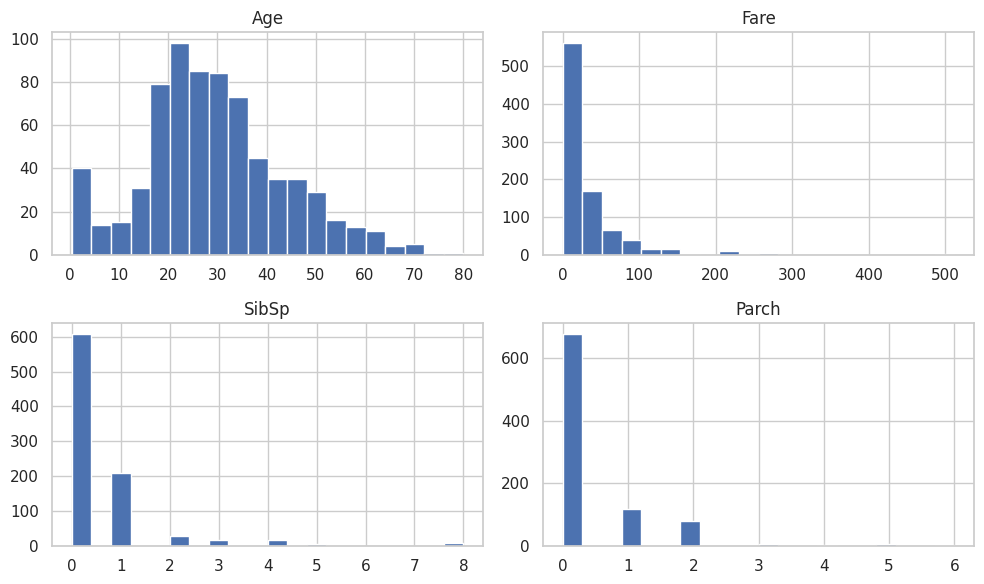

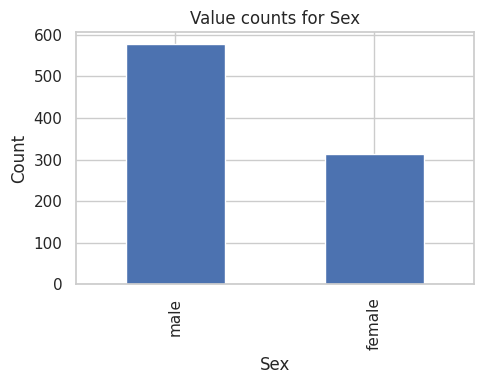

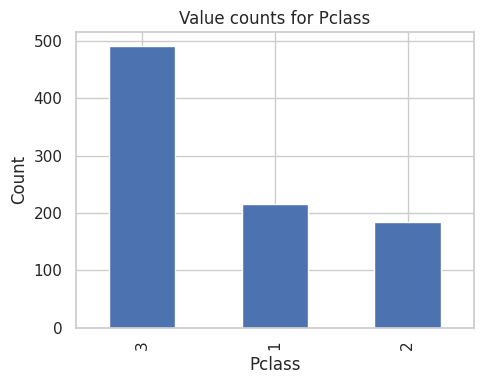

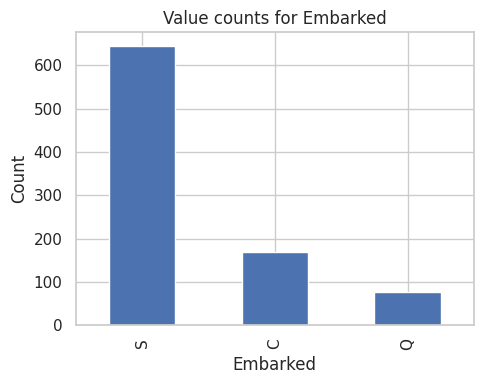

In [ ]:
# 2. Univariate Analysis

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Histograms code is written for you
df[numeric_cols].hist(bins=20, figsize=(10, 6))
plt.tight_layout()
plt.show()

# Write Countplots code for key categorical variables [You need to complete]
cat_cols = ["Sex", "Pclass", "Embarked"]

for c in cat_cols:
  plt.figure(figsize=(5,4))
  df[c].value_counts().plot(kind="bar")
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()


#### Write Your insights
- Insight 1:  Age data follows right skewed distribution. most passengers were in the 20 to 35 years old range.
- Insight 2:  Almost 500 passengers were from 3rd class. number of class 1 and class 2 passengers were slightly more than 200 and just below 200 respectively.
- Insight 3:  Most passenger Embarked from S (Southampton) and lowest from Q (Queenstown).

---
### 3. Bivariate Analysis with Target (15 marks)
Use `Survived` as the target variable.

**Tasks:**
- Compute and plot a **correlation heatmap** for numeric features, including `Survived`.
- Create a **pairplot** for: `Age`, `Fare`, `SibSp`, `Parch`, and `Survived`.
- Write **two to three insights**, including which variables seem associated with survival.


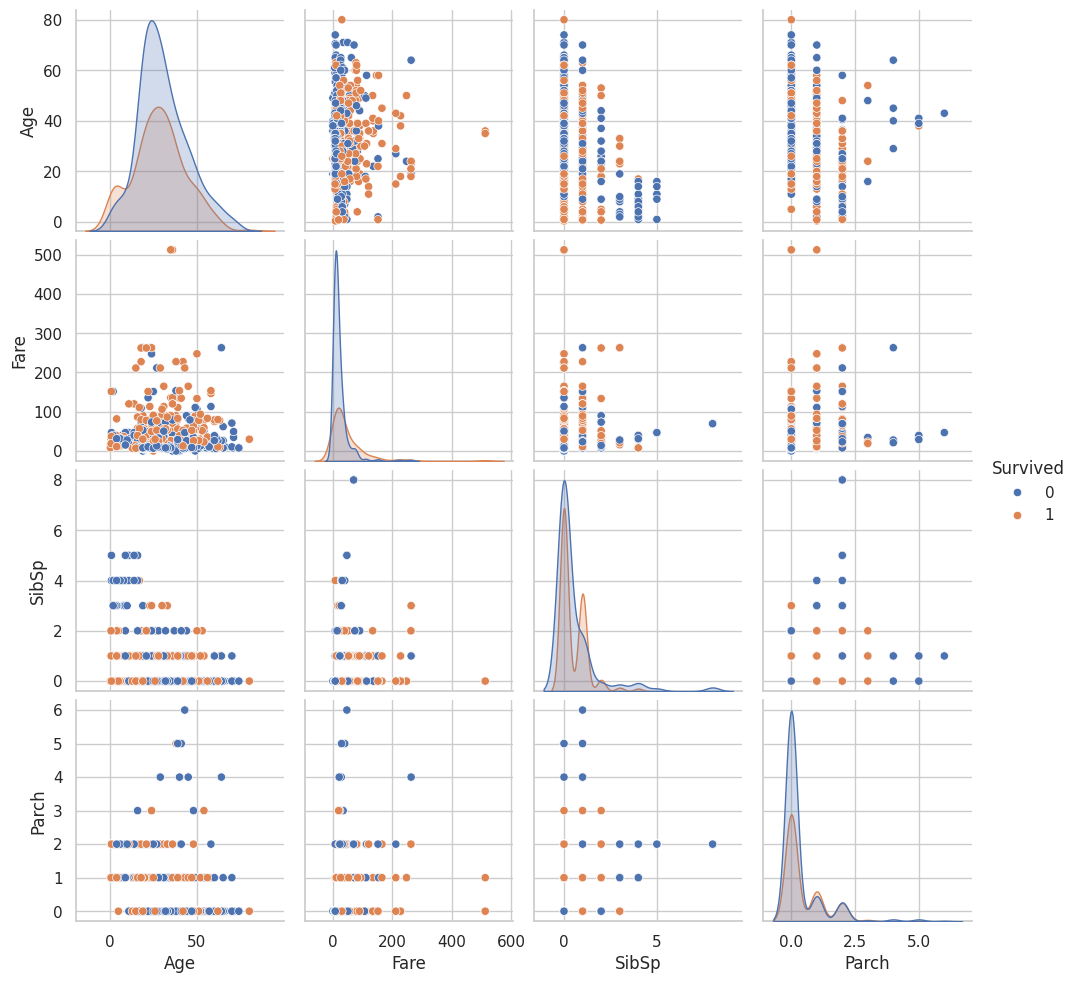

In [ ]:
# 3. Bivariate Analysis with Target

num_for_corr = ["Survived", "Age", "Fare", "SibSp", "Parch"]

## Complete this code block to generate correlation heatmap and pairplot [You need to complete]

sns.pairplot(df[["Survived", "Age", "Fare", "SibSp", "Parch"]],hue="Survived")
plt.show()

#### Your insights
- Insight 1:  Between Age and Fare, most survived passengers were below 50 years old and fare was between 50 to about 180. There was one single passenger with Fare more than 500 who survived.

- Insight 2:  Between no. of parents or children aboard the Titanic (Parch) and Fare, most passengers had from 0 to 2 and fare between 0 to 200. passenegers with more than 2, did not survive (except one case with value 3). Also, survival increases with the increases in fare.

- Insight 3:  Between (No. of siblings / spouses aboard the Titanic) SibSp and Age, most siblings or spouses were below 50 years old. also, most SibSp were from 0 to 2. With more than SibSp 3, nobody survived.

- From this i think, Age, Fare, Parch and  SibSp has strong correlation with survival.

---
### 4. Categorical vs Target Analysis (5 marks)
**Tasks:**
For each of the following categorical features: `Sex`, `Pclass`, `Embarked`:
- Plot a **bar chart** showing the proportion of passengers who survived in each category.
- Write **two short insights** about which categories have higher or lower survival chances.



Survival proportion by Sex:


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


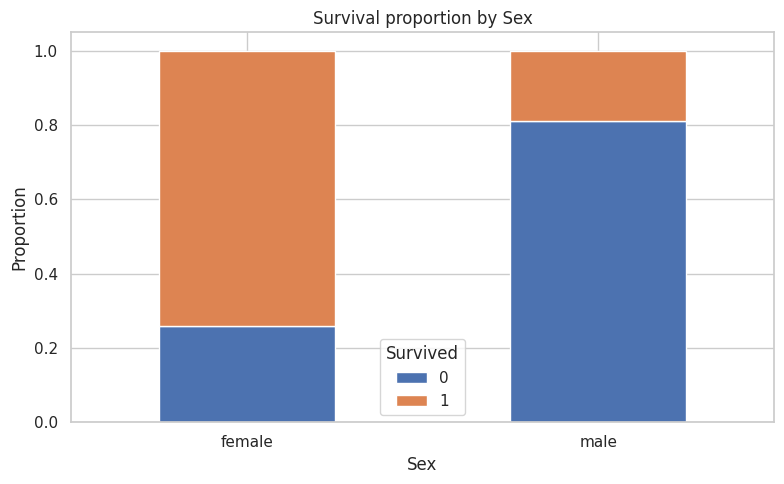


Survival proportion by Pclass:


Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


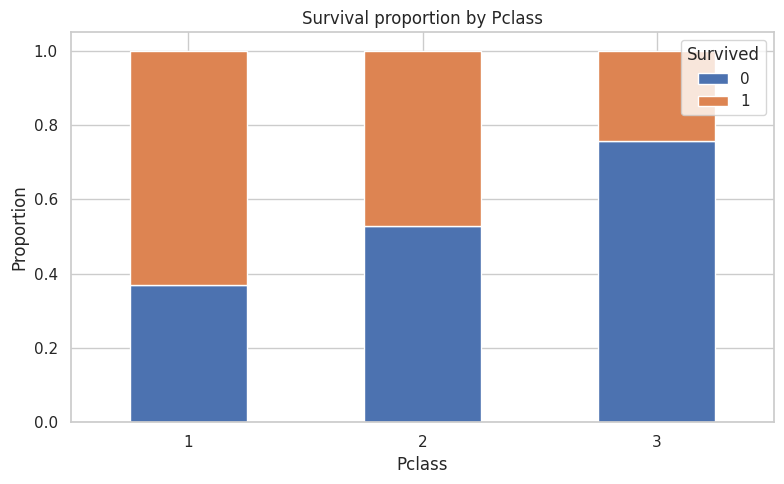


Survival proportion by Embarked:


Survived,0,1
Embarked,,
C,0.446429,0.553571
Q,0.610390,0.389610
S,0.663043,0.336957


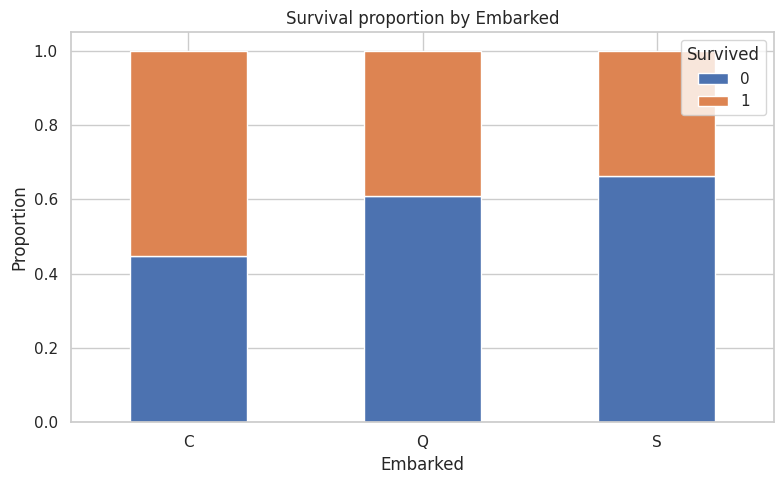

In [ ]:
# 4. Categorical vs Target Analysis [Bar chart code is written for you]

cat_target_cols = ["Sex", "Pclass", "Embarked"]

for c in cat_target_cols:
    ct = pd.crosstab(df[c], df["Survived"], normalize="index")
    print(f"\nSurvival proportion by {c}:")
    display(ct)
    ct.plot(kind="bar", stacked=True)
    plt.title(f"Survival proportion by {c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Your insights
- Insight 1:  Acording to sex feature column, almost 75% female survived. so females have better survival chances.
- Insight 2:  About 63% survied from class 1 in Pclass column. As a result, class 1 passenegrs have more possibility to survive.

Distribution of Embarked Column:


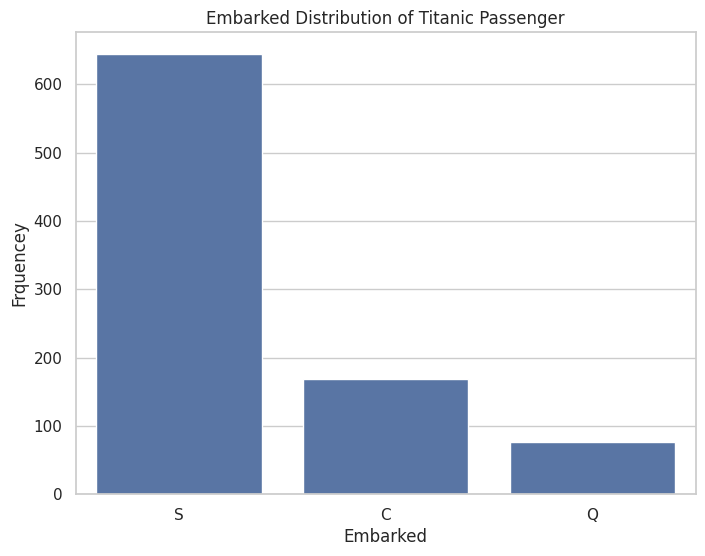

In [ ]:
print("Distribution of Embarked Column:")
plt.figure(figsize=(8,6))
sns.countplot(data=df, x="Embarked")
plt.title("Embarked Distribution of Titanic Passenger")
plt.xlabel("Embarked")
plt.ylabel("Frquencey")
plt.show()
#

---
## Part B: Basic Data Preprocessing – 45 marks

Focus: **Handling missing values, encoding categorical variables, and scaling numeric features.**

### 5. Handling Missing Values (15 marks)
**Tasks:**
1. Show the count of missing values in each column.
2. Decide how to handle missing values for:
   - `Age` (numeric)
   - `Embarked` (categorical)
   - `Cabin` (many missing values)
3. Implement your chosen strategy in code.
4. Show missing value counts again to confirm.
5. Explain your choices in **3–4 sentences**.


In [ ]:
# 5. Handling Missing Values

print("Missing values before:") #[Task 1 is done for you]
print(df.isna().sum())

# Drop Cabin (Complete this code block)
df = df.drop(columns=["Cabin"])

# Fill Age (Complete this code block)
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)

# Fill Embarked (Complete this code block)
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("\nMissing values after handling:")
print(df.isna().sum())

Missing values before:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### Explanation of your strategy
- Why you dropped or kept `Cabin`:  Cabin number is not important for survival prediction, also it has almost 77% data missing.
- Why you used median/mean for `Age`:  Age feature follows Right skewed distribution, for this we used medican for Age column to fill missing values.
- Why you used mode or another method for `Embarked`:  Among 3 categories in Embarked column, S has the highest frequency of about 650, whereas, C has below 200 Q has less than 100 passengers. So, to fill 2 missing values in Embarked column, its wise to use the mode of this column.

---
### 6. Encoding Categorical Variables (15 marks)
Focus on the following categorical features:
- `Sex`
- `Embarked`
- `Pclass` (treat as categorical)

**Tasks:**
- Use `OneHotEncoder` from sklearn to encode these features.
- Keep `Survived` and the main numeric features (`Age`, `Fare`, `SibSp`, `Parch`).
- Show the shape and head of the encoded DataFrame.


In [ ]:
# 6. Encoding Categorical Variables
df_enc = df.copy()

# Select features for encoding and keep important numeric ones
cat_features = ["Sex", "Embarked", "Pclass"]
numeric_features = ["Age", "Fare", "SibSp", "Parch"]
target_col = "Survived"

# One hot encode categorical variables [You need to do]
encoded_df = pd.get_dummies(
    df_enc,
    columns = cat_features,
    dtype=int
)

# display(encoded_df.head())
# print("Shape before concat:", encoded_df.shape)
# display(df_enc[[target_col] + numeric_features])

# Build final encoded DataFrame
df_model = pd.concat([
    df_enc[[target_col] + numeric_features],
    encoded_df
], axis=1)

print("Shape after encoding:", df_model.shape)
display(df_model.head())

Shape after encoding: (891, 21)


,Survived,Age,Fare,SibSp,Parch,PassengerId,Survived,Name,Age,SibSp,...,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,0,22.0,7.2500,1,0,1,0,"Braund, Mr. Owen Harris",22.0,1,...,A/5 21171,7.2500,0,1,0,0,1,0,0,1
1,1,38.0,71.2833,1,0,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,...,PC 17599,71.2833,1,0,1,0,0,1,0,0
2,1,26.0,7.9250,0,0,3,1,"Heikkinen, Miss. Laina",26.0,0,...,STON/O2. 3101282,7.9250,1,0,0,0,1,0,0,1
3,1,35.0,53.1000,1,0,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,...,113803,53.1000,1,0,0,0,1,1,0,0
4,0,35.0,8.0500,0,0,5,0,"Allen, Mr. William Henry",35.0,0,...,373450,8.0500,0,1,0,0,1,0,0,1


---
### 7. Scaling Numeric Features (15 marks)
**Tasks:**
- Use `StandardScaler` on the numeric features: `Age`, `Fare`, `SibSp`, `Parch`.
- Plot boxplots of these features **before** and **after** scaling.
- Write **two sentences** explaining how scaling changes the numeric values and why it is useful before training some ML models.


In [ ]:
# df_model.info()
# print(df_model.isna().sum()) # check for null

In [ ]:
# print(df_model.columns)

print(df_model.columns[df_model.columns.duplicated()]) # some duplicate columns, need to remove them

Index(['Survived', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [ ]:
df_model = df_model.loc[:, ~df_model.columns.duplicated()] # removes duplicate columns
# print(df_model.columns)

print(df_model.columns[df_model.columns.duplicated()])

Index([], dtype='object')


In [ ]:
# df_model.info()
# df_model[["Age", "Fare", "SibSp", "Parch"]].describe()

In [ ]:
# print("model", df_model.shape)
# df_model.head()

In [ ]:
# # for chekcing
# score_cols = ["Age", "Fare", "SibSp", "Parch"]


# # print(score_cols)
# print("model", df_model.shape)

# # Apply StandardScaler [You need to do]
# scaler_sd = StandardScaler()
# df_scaled_array = scaler_sd.fit_transform(df_model[score_cols])
# print("array shape", df_scaled_array.shape)
# df_scaled = pd.DataFrame(df_scaled_array, columns=score_cols,  index=df_model.index)
# print("df scaled shape", df_scaled.shape)


# # Drop the columns
# df_model = df_model.drop(columns=score_cols)

# # Check the result
# print("after drop df model shape",df_model.shape)


# # Build final encoded DataFrame
# df_scaled = pd.concat([
#     df_model,df_scaled
# ], axis=1)


# print("df model", df_model.shape)
# print("df scaled", df_scaled.shape)

In [ ]:
# display(df_model.head())
# df_scaled.head()

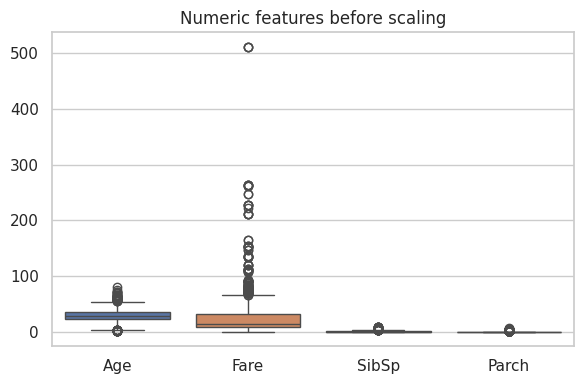

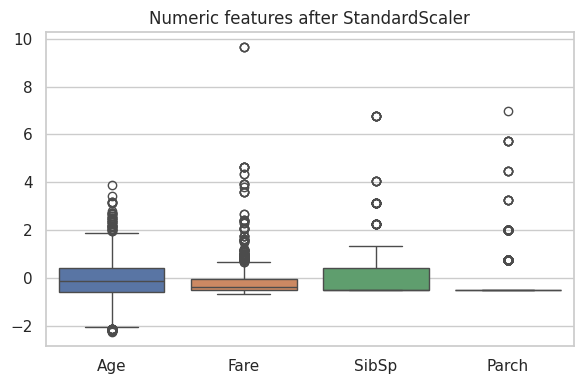

In [ ]:
# 7. Scaling Numeric Features

score_cols = ["Age", "Fare", "SibSp", "Parch"]

# Boxplot before scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_model[score_cols])
plt.title("Numeric features before scaling")
plt.tight_layout()
plt.show()

# Apply StandardScaler [You need to do]

# print("model", df_model.shape)

scaler_sd = StandardScaler()
df_scaled_array = scaler_sd.fit_transform(df_model[score_cols])
# print("array shape", df_scaled_array.shape)
df_scaled = pd.DataFrame(df_scaled_array, columns=score_cols,  index=df_model.index)
# print("df scaled shape", df_scaled.shape)

# Drop the columns score_cols from df_model
df_model = df_model.drop(columns=score_cols)

# Check the result
# print("after drop df model shape",df_model.shape)


# Now concat df_model and df_scaled into df_scaled
df_scaled = pd.concat([df_model, df_scaled], axis=1)


# print("after concat df model", df_model.shape)
# print("after concat df scaled", df_scaled.shape)


# Boxplot after scaling
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_scaled[score_cols])
plt.title("Numeric features after StandardScaler")
plt.tight_layout()
plt.show()

#### Your observations on scaling
- Sentence 1: Before scaling- Age, Fare, SibSp, Parch had max values of 80,	512.3, 8,	6 respectively. Age and fare had greater values comparede to the other two. so scaling is needed to bring them in a similar scale. After scaling their max values are 3.89, 9.66, 6.78, 6.94 respectively.
- Sentence 2:  Previously SD values were 13.01,	49.69,	1.10,	0.80, after scaling they are almost 1. Moreover, I think there is an outlier in Fare feature, if we remove that, i think , scaling will bring them in a more uniform scale. This way, dataset can be more useful for ML algorithms.

---
### 8. Simple Feature Quality Check (5 marks)
**Tasks:**
- Show `.info()` of the final processed DataFrame (`df_scaled`).
- Confirm there are no missing values.
- Confirm that all remaining features are numeric and suitable for most ML models.
- Write **one short concluding remark** about dataset readiness.


In [ ]:
# display(df_model.head())
# df_scaled.head()

# print(df_model.info())
# print(df_scaled.info())

In [ ]:
# 8. Simple Feature Quality Check
print(df_scaled.info())

print("\nTotal missing values in final DataFrame:", df_scaled.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Name         891 non-null    object 
 3   Ticket       891 non-null    object 
 4   Sex_female   891 non-null    int64  
 5   Sex_male     891 non-null    int64  
 6   Embarked_C   891 non-null    int64  
 7   Embarked_Q   891 non-null    int64  
 8   Embarked_S   891 non-null    int64  
 9   Pclass_1     891 non-null    int64  
 10  Pclass_2     891 non-null    int64  
 11  Pclass_3     891 non-null    int64  
 12  Age          891 non-null    float64
 13  Fare         891 non-null    float64
 14  SibSp        891 non-null    float64
 15  Parch        891 non-null    float64
dtypes: float64(4), int64(10), object(2)
memory usage: 111.5+ KB
None

Total missing values in final DataFrame: 0


In [ ]:
# drop Name and Ticket
df_scaled = df_scaled.drop(columns=["Name", "Ticket"])
print(df_scaled.info())
df_scaled.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Sex_female   891 non-null    int64  
 3   Sex_male     891 non-null    int64  
 4   Embarked_C   891 non-null    int64  
 5   Embarked_Q   891 non-null    int64  
 6   Embarked_S   891 non-null    int64  
 7   Pclass_1     891 non-null    int64  
 8   Pclass_2     891 non-null    int64  
 9   Pclass_3     891 non-null    int64  
 10  Age          891 non-null    float64
 11  Fare         891 non-null    float64
 12  SibSp        891 non-null    float64
 13  Parch        891 non-null    float64
dtypes: float64(4), int64(10)
memory usage: 97.6 KB
None


,Survived,PassengerId,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3,Age,Fare,SibSp,Parch
0,0,1,0,1,0,0,1,0,0,1,-0.565736,-0.502445,0.432793,-0.473674
1,1,2,1,0,1,0,0,1,0,0,0.663861,0.786845,0.432793,-0.473674
2,1,3,1,0,0,0,1,0,0,1,-0.258337,-0.488854,-0.474545,-0.473674
3,1,4,1,0,0,0,1,1,0,0,0.433312,0.420730,0.432793,-0.473674
4,0,5,0,1,0,0,1,0,0,1,0.433312,-0.486337,-0.474545,-0.473674
5,0,6,0,1,0,1,0,0,0,1,-0.104637,-0.478116,-0.474545,-0.473674
6,0,7,0,1,0,0,1,1,0,0,1.893459,0.395814,-0.474545,-0.473674
7,0,8,0,1,0,0,1,0,0,1,-2.102733,-0.224083,2.247470,0.767630
8,1,9,1,0,0,0,1,0,0,1,-0.181487,-0.424256,-0.474545,2.008933
9,1,10,1,0,1,0,0,0,1,0,-1.180535,-0.042956,0.432793,-0.473674


#### Final remark on dataset readiness
- Your remark:  initially as all data were not in numeric format, encoding is done on catagorical columns. scaling is done on certain numerical columns to make the dataset more suitable for ML algorithms. Name, Ticket, Cabin columns are too random to have any impact on model performance, so they are dropped here. Also Passenger ID can be removed.
- I think now the dataset is ready for ML algorithms.

---
## Submission
- Run all cells from top to bottom to make sure everything works.
- Set the Colab file's shareable link to ‘Anyone with the link’ and ‘View’ access, then submit it in the Phitron Assignment module's Assignment submission section.